In [3]:
!pip install nltk
!pip install tensorflow

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Dataset Loaded Successfully
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive

Text Preprocessing Completed

TF-IDF Feature Extraction Completed

Training Naïve Bayes Model...
Naïve Bayes Accuracy: 0.825

Training Logistic Regression Model...
Logistic Regression Accuracy: 0.866

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.85      0.87       530
           1       0.84      0.88      0.86       470

    accuracy                           0.87      1000
   macro avg       0.87      0.87      0.87      1000
weighted avg       0.87      0.87      0.87      1000



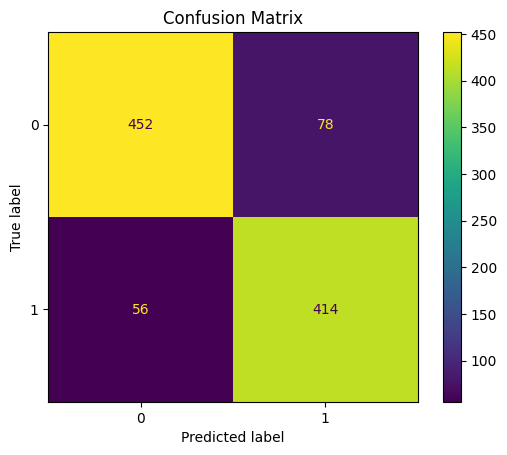


Preparing Data for LSTM Model...

Building LSTM Model...

Training LSTM Model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


63/63 ━━━━━━━━━━━━━━━━━━━━ 22s 302ms/step - accuracy: 0.6860 - loss: 0.5786 - val_accuracy: 0.8360 - val_loss: 0.3900


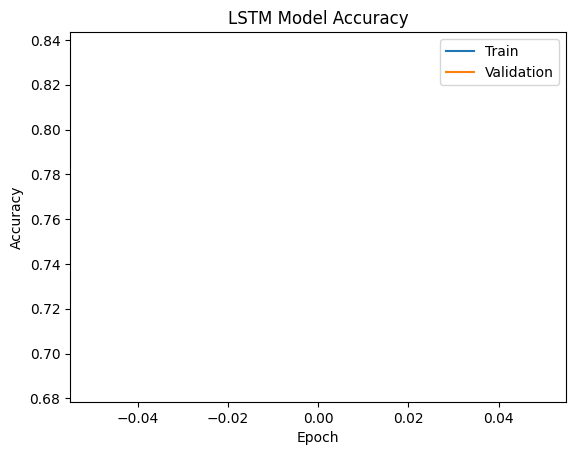


Model Saved Successfully

Custom Review Prediction:
Positive Sentiment

Sentiment Analysis Project Completed


In [4]:
# ============================================
# AI-Based Sentiment Analysis System
# Final Capstone Project
# ============================================

# Import Libraries
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import pickle

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Embedding
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Download Stopwords
nltk.download('stopwords')

# ============================================
# Load Dataset
# ============================================

dataset = pd.read_csv("IMDB Dataset.csv")

# Reduce dataset size for faster execution
dataset = dataset.head(5000)

print("Dataset Loaded Successfully")
print(dataset.head())

# ============================================
# Text Preprocessing
# ============================================

ps = PorterStemmer()

def clean_text(text):

    # Remove special characters
    text = re.sub('[^a-zA-Z]', ' ', text)

    # Convert to lowercase
    text = text.lower()

    # Split words
    words = text.split()

    # Remove stopwords and stemming
    words = [
        ps.stem(word)
        for word in words
        if word not in stopwords.words('english')
    ]

    return ' '.join(words)

# Apply preprocessing
dataset['clean_review'] = dataset['review'].apply(clean_text)

print("\nText Preprocessing Completed")

# ============================================
# Convert Labels
# ============================================

dataset['sentiment'] = dataset['sentiment'].map({
    'positive': 1,
    'negative': 0
})

# ============================================
# TF-IDF Feature Extraction
# ============================================

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(dataset['clean_review']).toarray()

y = dataset['sentiment']

print("\nTF-IDF Feature Extraction Completed")

# ============================================
# Train-Test Split
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ============================================
# Naïve Bayes Model
# ============================================

print("\nTraining Naïve Bayes Model...")

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

nb_accuracy = accuracy_score(y_test, nb_pred)

print("Naïve Bayes Accuracy:", nb_accuracy)

# ============================================
# Logistic Regression Model
# ============================================

print("\nTraining Logistic Regression Model...")

lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

# ============================================
# Classification Report
# ============================================

print("\nClassification Report:\n")

print(classification_report(y_test, lr_pred))

# ============================================
# Confusion Matrix
# ============================================

cm = confusion_matrix(y_test, lr_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Confusion Matrix")

plt.show()

# ============================================
# Deep Learning - LSTM Model
# ============================================

print("\nPreparing Data for LSTM Model...")

tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(dataset['clean_review'])

X_seq = tokenizer.texts_to_sequences(dataset['clean_review'])

X_pad = pad_sequences(X_seq, maxlen=200)

X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    X_pad,
    y,
    test_size=0.2,
    random_state=42
)

# ============================================
# Build LSTM Model
# ============================================

print("\nBuilding LSTM Model...")

model = Sequential()

model.add(Embedding(5000, 128, input_length=200))

model.add(LSTM(64))

model.add(Dense(1, activation='sigmoid'))

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# ============================================
# Train LSTM Model
# ============================================

print("\nTraining LSTM Model...")

history = model.fit(
    X_train_dl,
    y_train_dl,
    epochs=1,
    batch_size=64,
    validation_data=(X_test_dl, y_test_dl)
)

# ============================================
# Plot Accuracy Graph
# ============================================

plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title('LSTM Model Accuracy')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.show()

# ============================================
# Save Models
# ============================================

pickle.dump(lr_model, open('sentiment_model.pkl', 'wb'))

pickle.dump(tfidf, open('tfidf_vectorizer.pkl', 'wb'))

print("\nModel Saved Successfully")

# ============================================
# Predict Custom Review
# ============================================

sample_review = "This movie was absolutely fantastic and amazing"

sample_clean = clean_text(sample_review)

sample_vector = tfidf.transform([sample_clean]).toarray()

prediction = lr_model.predict(sample_vector)

print("\nCustom Review Prediction:")

if prediction[0] == 1:
    print("Positive Sentiment")
else:
    print("Negative Sentiment")

# ============================================
# Final Output
# ============================================

print("\n====================================")
print("Sentiment Analysis Project Completed")
print("====================================")